# Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb


from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler


# Datasets loading

In [2]:
url1 = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
df1 = pd.read_csv(url1) #training models

- HUFL, HULL: High-usage frequency limits (upper/lower)
- MUFL, MULL: Medium-usage frequency limits (upper/lower)
- LUFL, LULL:
- OT: Operational Temperature (target variable)

# Analyse du jeu de donnée ETTH1

In [3]:
print(df1.head())
print('*'*20)

print(df1.shape)
print('*'*20)

print("Shape :",df1.shape)
print('*'*20)

print("Columns :",df1.columns)
print('*'*20)

df1.rename(columns=lambda x: x + "_1" if x != 'date' and x[-2::] != "_1" else x, inplace=True)
print("Global information :\n", df1.info(),"\n",'-'*20,"\n")
print('*'*20)

print("NaN values for each column :\n", df1.isna().sum())
print('*'*20)

print("Number of duplicated measures :",df1.duplicated().sum())
print('*'*20)

                  date   HUFL   HULL   MUFL   MULL   LUFL   LULL         OT
0  2016-07-01 00:00:00  5.827  2.009  1.599  0.462  4.203  1.340  30.531000
1  2016-07-01 01:00:00  5.693  2.076  1.492  0.426  4.142  1.371  27.787001
2  2016-07-01 02:00:00  5.157  1.741  1.279  0.355  3.777  1.218  27.787001
3  2016-07-01 03:00:00  5.090  1.942  1.279  0.391  3.807  1.279  25.044001
4  2016-07-01 04:00:00  5.358  1.942  1.492  0.462  3.868  1.279  21.948000
********************
(17420, 8)
********************
Shape : (17420, 8)
********************
Columns : Index(['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT'], dtype='str')
********************
<class 'pandas.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    17420 non-null  str    
 1   HUFL_1  17420 non-null  float64
 2   HULL_1  17420 non-null  float64
 3   MUFL_1  17420 non-null  float64
 4   MULL_1  17420

In [4]:
df1['date'] = pd.to_datetime(df1['date'])
df1.set_index('date', inplace=True)
counts_per_day = df1.resample('D').size()
freq_data_day = round(counts_per_day.mean())
print("Fréquence des données (nombre de mesures/jour) :", freq_data_day)
print("Nombre de jours représentés par la série :", df1.index.max() - df1.index.min())
df1.describe().T

Fréquence des données (nombre de mesures/jour) : 24
Nombre de jours représentés par la série : 725 days 19:00:00


,count,mean,std,min,25%,50%,75%,max
HUFL_1,17420.0,7.375141,7.067744,-22.705999,5.827,8.774,11.788,23.643999
HULL_1,17420.0,2.242242,2.042342,-4.756000,0.737,2.210,3.684,10.114000
MUFL_1,17420.0,4.300239,6.826978,-25.087999,3.296,5.970,8.635,17.341000
MULL_1,17420.0,0.881568,1.809293,-5.934000,-0.284,0.959,2.203,7.747000
LUFL_1,17420.0,3.066062,1.164506,-1.188000,2.315,2.833,3.625,8.498000
LULL_1,17420.0,0.856932,0.599552,-1.371000,0.670,0.975,1.218,3.046000
OT_1,17420.0,13.324672,8.566946,-4.080000,6.964,11.396,18.079,46.007000


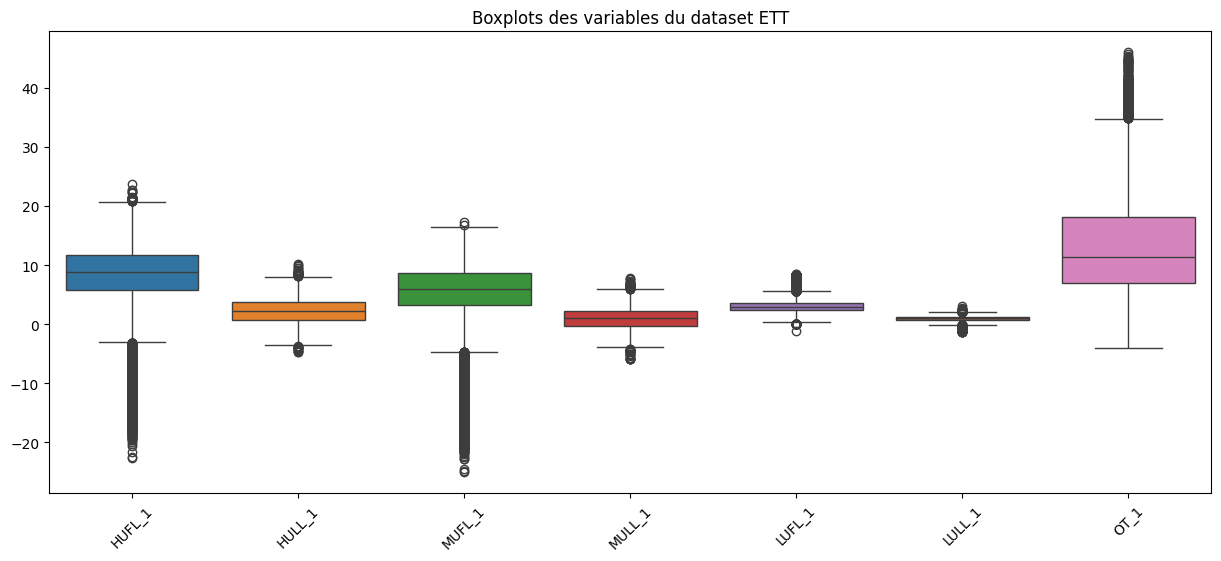

In [5]:
df_numeric = df1.select_dtypes(include=['number'])

plt.figure(figsize=(15, 6))
sns.boxplot(data=df_numeric)
plt.title("Boxplots des variables du dataset ETT")
plt.xticks(rotation=45)
plt.show()

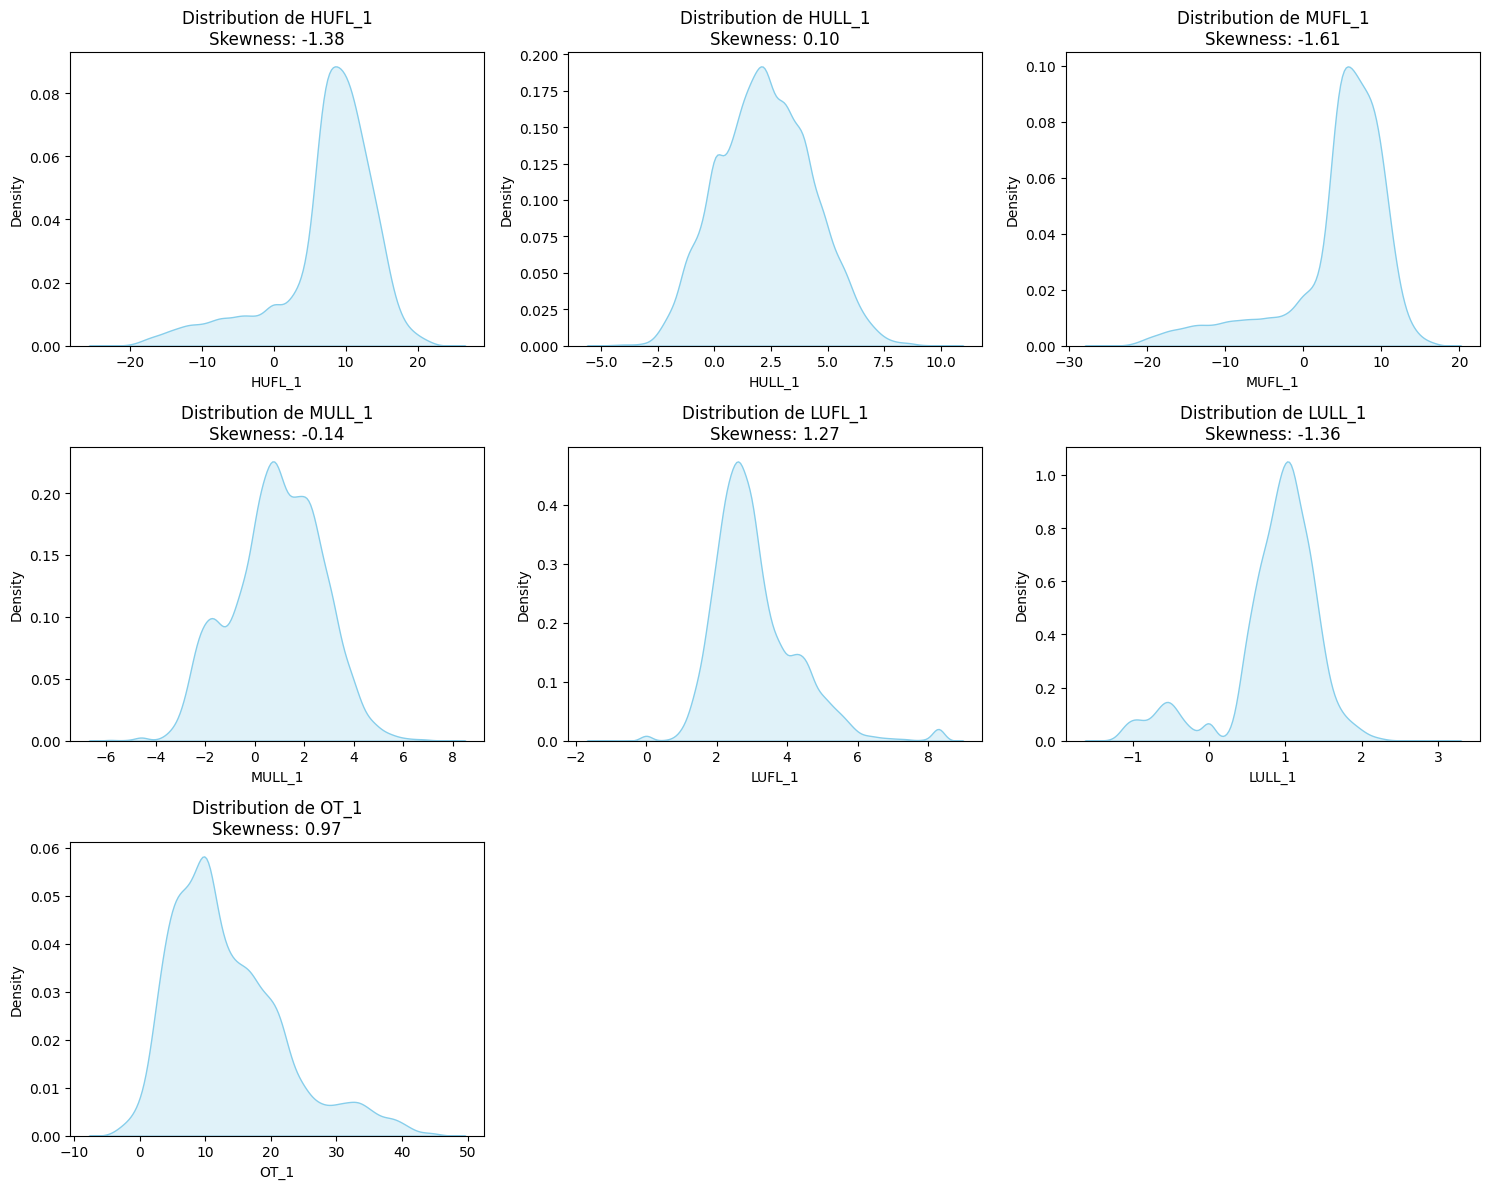

In [6]:
n_cols = len(df_numeric.columns)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(df_numeric.columns):
    skew_val = df_numeric[col].skew()
    sns.kdeplot(df_numeric[col], fill=True, color="skyblue", ax=axes[i])
    axes[i].set_title(f"Distribution de {col}\nSkewness: {skew_val:.2f}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

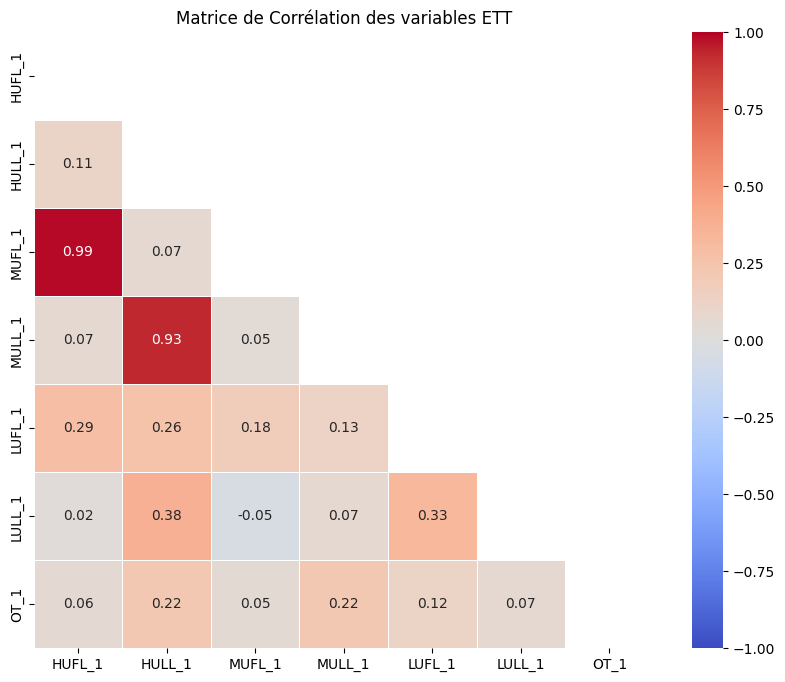

In [7]:
corr = df_numeric.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, 
            mask=mask, 
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            vmin=-1, vmax=1,
            center=0,
            linewidths=.5)

plt.title("Matrice de Corrélation des variables ETT")
plt.show()

MUFL et HUFL : 99%:
- Somme absolute des correlations % MUFL\{HUFL} : 0,4
- Somme absolute des correlations % HUFL\{MUFL} : 0,55 (Plus corrélé aux autres que MUFL, on supprime HUFL !)

MULL et HULL : 93%:
- Somme absolute des correlations % MULL\{HULL} : 0,54
- Somme absolute des correlations % HULL\{MULL} : 1,04
- Somme absolute des correlations % MULL\{HULL,HUFL} : 0,25
- Somme absolute des correlations % HULL\{MULL,HUFL} : 0,93
- HULL est bien plus corrélé aux autres que MULL, même en comptant la suppression de HUFL, on supprime HULL !

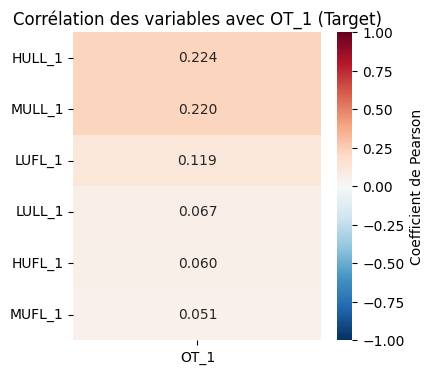

In [8]:
target_corr = corr[['OT_1']].drop(labels=['OT_1']).sort_values(by='OT_1', ascending=False)
plt.figure(figsize=(4, 4))
sns.heatmap(target_corr, 
            annot=True, 
            fmt=".3f", 
            cmap='RdBu_r',
            vmin=-1, vmax=1, 
            center=0,
            cbar_kws={'label': 'Coefficient de Pearson'})
plt.title("Corrélation des variables avec OT_1 (Target)")
plt.show()

Attention, on remarque qu'on supprime HULL, la variable la plus corrélée à la target ! Cependant, HULL étant fortement corrélé a MULL, on observe que MULL est également bien corrélé avec la taregt, seulement 4 millièmes de moins, ce qui est négligeable, et donc la suppression de HULL n'a pas d'incidence majeur.

In [9]:
df1.drop(columns=["HUFL_1","HULL_1"], inplace=True)

# Modélisation de la serie temporelle univariée de la température de l'huile (target)

On ne reproduit pas les plots qui sont déjà dans le notebook "ARIMA"

<Axes: >

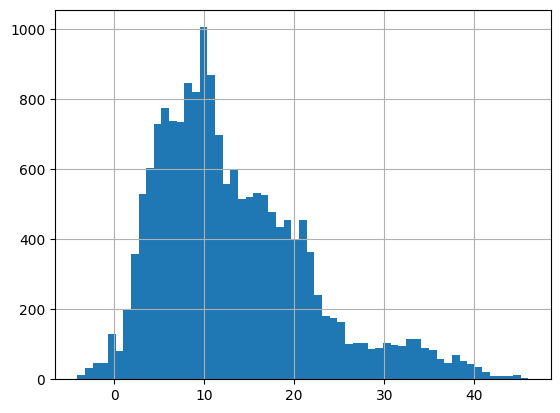

In [10]:
univariate = pd.DataFrame(df1['OT_1'].copy())
univariate['OT_1'].hist(bins='auto')

## Train / Test split

In [11]:
train_size = int(univariate.shape[0] * 0.8)

train = univariate.iloc[:train_size]
test  = univariate.iloc[train_size:]

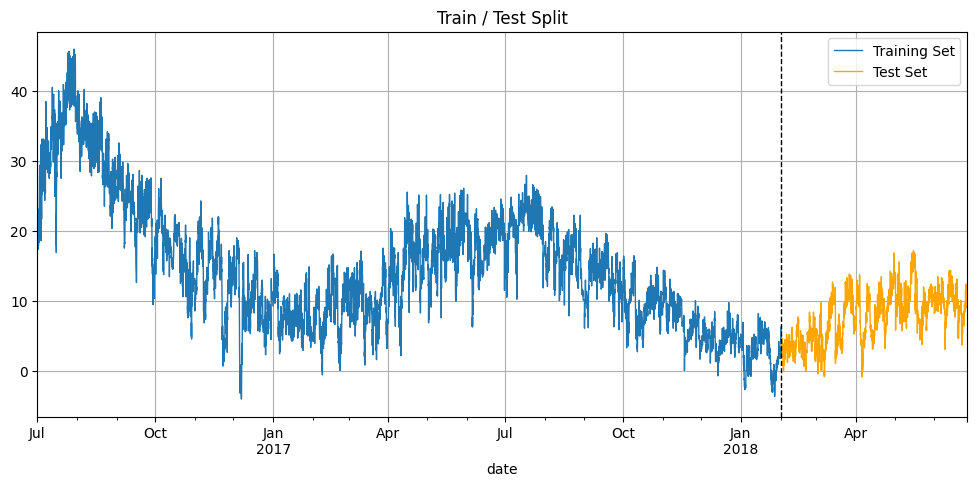

In [12]:
fig, ax = plt.subplots(figsize=(12,5))
train.plot(title ="Train / Test Split", lw=1, ax=ax)
test.plot(color="orange", lw=1, ax=ax)
ax.axvline(univariate.index[train_size], color="black", ls="dashed", lw=1)
plt.legend(["Training Set", "Test Set"])
plt.grid()
plt.show()

## Time Series Cross Validation (Forward Validation)

In [13]:
# TimeSeriesSplit
#   n_splits == k_fold
#   max_train_size : Maximum size for a single training set.
#   test_size : limit the size of the test set. Defaults to n_samples // (n_splits + 1), which is the maximum allowed value with gap=0.
#   gap : Number of samples to exclude from the end of each train set before the test set.

In [14]:
test_size=2880
n_folds = 5
tss = TimeSeriesSplit(n_splits=n_folds, test_size = test_size, gap=24) #test_size = 2880 heures (référence du dataset)
#test_size = 7j !
# gap simule le délai réel de disponibilité des données en production, disons ici 12h

# GAP = 0 ou 2

/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/pandas/plotting/_matplotlib/core.py:997: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


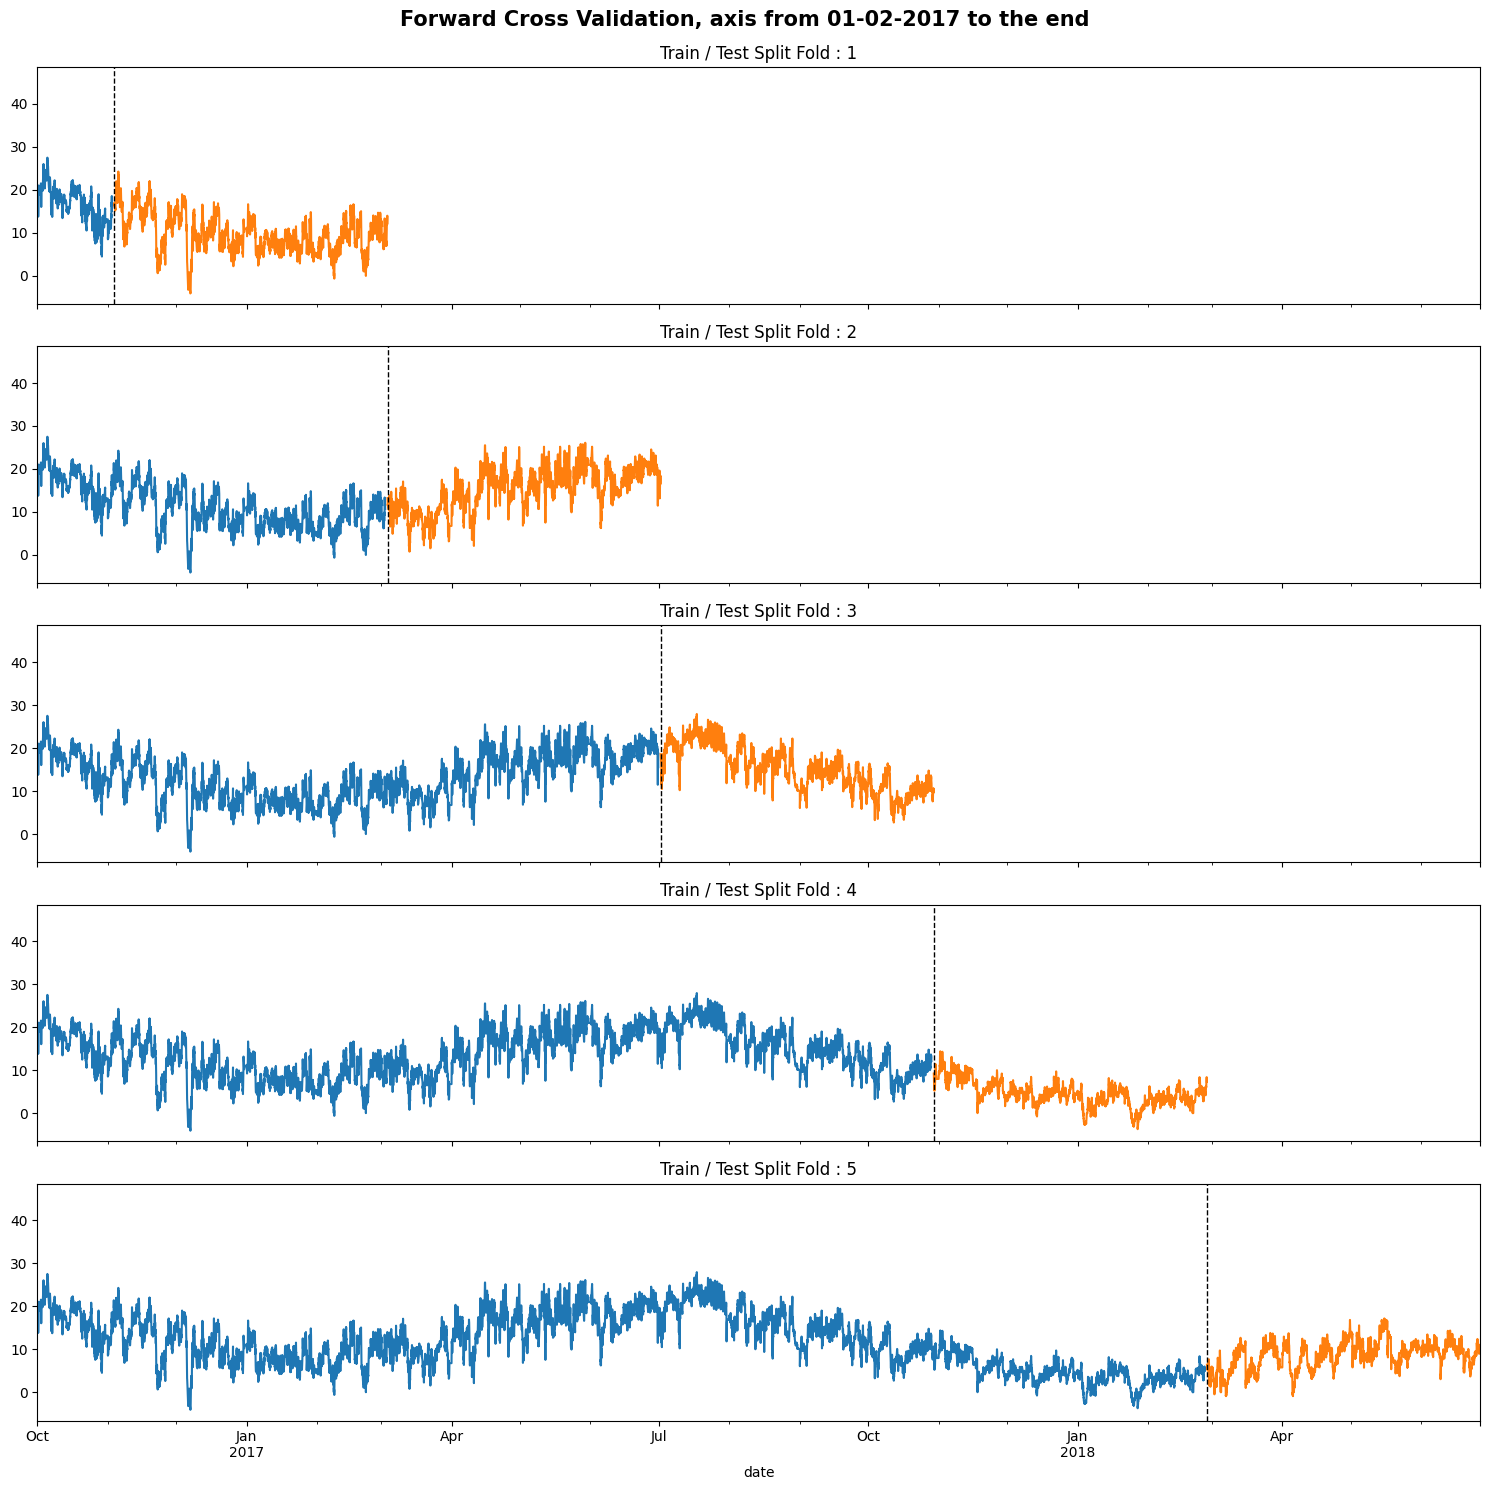

In [15]:
univariate_train = univariate.iloc[24:]
univariate_test  = univariate.iloc[:24]

fig, axs = plt.subplots(n_folds,1, figsize=(15,15), sharex=True)
fig.suptitle("Forward Cross Validation, axis from 01-02-2017 to the end",
             fontsize=15, 
             fontweight='bold', 
             y=0.99)
fold = 0
for train_idx, test_idx in tss.split(univariate_train):
    train = univariate_train.iloc[train_idx]
    test  = univariate_train.iloc[test_idx]
    train["OT_1"].plot(ax=axs[fold],
                       label="Training Set",
                       title=f"Train / Test Split Fold : {fold+1}")
    test["OT_1"].plot(ax=axs[fold],
                      label="Test Set")
    axs[fold].axvline(test.index.min(), color="black", lw=1, ls="dashed")
    axs[-1].set_xlim(pd.Timestamp('2016-10-01'), univariate_train.index.max())
    fold+=1
    plt.tight_layout()

## Forecasting Horizon

In [16]:
def create_features(df):

    df = df.copy()
    df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)   
    df['dayofweek'] = df.index.dayofweek
    df['quarter']   = df.index.quarter
    df["month"]     = df.index.month
    df["year"]      = df.index.year
    df["dayofyear"] = df.index.dayofyear
    df["dayofmonth"]= df.index.day
    df["weekofyear"]= df.index.isocalendar().week
    return df

## Lag features
# Dis au modèle de regarder dans le passé, de x jours, et d'utiliser les targets de ces valeurs passées comme une nouvelle feature à fit dans le modèle.
def add_lags(df):
    target_map = df['OT_1'].to_dict()
    df["lag1"] = (df.index - pd.Timedelta("1 hour")).map(target_map)
    df["lag2"] = (df.index - pd.Timedelta("2 hours")).map(target_map)
    df["lag3"] = (df.index - pd.Timedelta("3 hours")).map(target_map)
    df["lag4"] = (df.index - pd.Timedelta("4 hours")).map(target_map)
    df["lag5"] = (df.index - pd.Timedelta("5 hours")).map(target_map)
    df["lag6"] = (df.index - pd.Timedelta("6 hours")).map(target_map)
    df["lag7"] = (df.index - pd.Timedelta("7 hours")).map(target_map)
    df["lag24"] = (df.index - pd.Timedelta("24 hours")).map(target_map)
    df["lag48"] = (df.index - pd.Timedelta("48 hours")).map(target_map) #2j
    df["lag168"] = (df.index - pd.Timedelta("168 hours")).map(target_map) # 7j

    return df

## Training using CrossValidation

In [17]:
univariate = create_features(univariate)
univariate = add_lags(univariate)

In [40]:
univariate_train = univariate.iloc[:-24]
univariate_test  = univariate.iloc[-24:]
y = "OT_1"
X = list(univariate_train.drop(columns=[y]).columns)

base_model = xgb.XGBRegressor()

param_dist = {
    'estimator__n_estimators': [800, 1000, 1200],
    'estimator__subsample': [0.8, 1],
    'estimator__colsample_bytree': [0.6, 0.8, 1],
    'estimator__learning_rate': [0.01],
    'estimator__max_depth': [1, 2],
    'estimator__min_samples_split': [2, 3, 4],
    'estimator__scale_pos_weight': [0.8, 1],
    'estimator__n_jobs': [-1],
    'estimator__random_state': [42],

}

random_search_1 = RandomizedSearchCV(
    base_model, 
    param_distributions=param_dist, 
    cv=tss,
    scoring='neg_mean_squared_error',
    n_iter=150,
    n_jobs=-1
)

X_train = univariate_train[X]
y_train = univariate_train[y]

random_search_1.fit(X_train, y_train)
best_params1 = random_search_1.best_params_
clean_params1 = {k.replace('estimator__', ''): v for k, v in best_params1.items()}
print("Paramètres optimaux extraits :", clean_params1)


/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:08:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "estimator__colsample_bytree", "estimator__learning_rate", "estimator__max_depth", "estimator__min_samples_split", "estimator__n_estimators", "estimator__n_jobs", "estimator__random_state", "estimator__scale_pos_weight", "estimator__subsample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:08:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "estimator__colsample_bytree", "estimator__learning_rate", "estimator__max_depth", "estimator__min_samples_split", "estimator__n_estimators", "estimator__n_jobs", "estimator__random_state", "estimator__scale_pos_weight", "estimator__subsample" } are not used.

  bst.update

Paramètres optimaux extraits : {'subsample': 0.8, 'scale_pos_weight': 0.8, 'random_state': 42, 'n_jobs': -1, 'n_estimators': 1000, 'min_samples_split': 2, 'max_depth': 2, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:08:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "estimator__colsample_bytree", "estimator__learning_rate", "estimator__max_depth", "estimator__min_samples_split", "estimator__n_estimators", "estimator__n_jobs", "estimator__random_state", "estimator__scale_pos_weight", "estimator__subsample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [41]:
preds, scores = [], []
for train_idx, test_idx in tss.split(univariate_train):
    train = univariate_train.iloc[train_idx]
    test  = univariate_train.iloc[test_idx]

    X_train = train[X]
    y_train = train[y]

    X_test = test[X]
    y_test = test[y]

    regression = xgb.XGBRegressor(**clean_params1)

    
    regression.fit(X_train, y_train,
                   eval_set=[(X_train, y_train), (X_test, y_test)],
                   verbose=20)
    y_pred = regression.predict(X_test)
    preds.append(y_pred)
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(score)


[0]	validation_0-rmse:8.04203	validation_1-rmse:16.83191
[20]	validation_0-rmse:6.74877	validation_1-rmse:14.81200


/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:08:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[40]	validation_0-rmse:5.68406	validation_1-rmse:13.13645
[60]	validation_0-rmse:4.81035	validation_1-rmse:11.68644
[80]	validation_0-rmse:4.09175	validation_1-rmse:10.43693
[100]	validation_0-rmse:3.50104	validation_1-rmse:9.43624
[120]	validation_0-rmse:3.01717	validation_1-rmse:8.49563
[140]	validation_0-rmse:2.62358	validation_1-rmse:7.65687
[160]	validation_0-rmse:2.30443	validation_1-rmse:6.95232
[180]	validation_0-rmse:2.04569	validation_1-rmse:6.32408
[200]	validation_0-rmse:1.83890	validation_1-rmse:5.84525
[220]	validation_0-rmse:1.67397	validation_1-rmse:5.42103
[240]	validation_0-rmse:1.54533	validation_1-rmse:5.00398
[260]	validation_0-rmse:1.44413	validation_1-rmse:4.73616
[280]	validation_0-rmse:1.36465	validation_1-rmse:4.43829
[300]	validation_0-rmse:1.30254	validation_1-rmse:4.16388
[320]	validation_0-rmse:1.25395	validation_1-rmse:3.96345
[340]	validation_0-rmse:1.21563	validation_1-rmse:3.77175
[360]	validation_0-rmse:1.18524	validation_1-rmse:3.58032
[380]	validati

/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:08:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[240]	validation_0-rmse:1.70827	validation_1-rmse:1.21413
[260]	validation_0-rmse:1.56323	validation_1-rmse:1.17860
[280]	validation_0-rmse:1.44805	validation_1-rmse:1.15197
[300]	validation_0-rmse:1.35734	validation_1-rmse:1.13475
[320]	validation_0-rmse:1.28674	validation_1-rmse:1.12406
[340]	validation_0-rmse:1.23165	validation_1-rmse:1.11594
[360]	validation_0-rmse:1.18780	validation_1-rmse:1.10926
[380]	validation_0-rmse:1.15358	validation_1-rmse:1.10251
[400]	validation_0-rmse:1.12625	validation_1-rmse:1.09461
[420]	validation_0-rmse:1.10383	validation_1-rmse:1.08730
[440]	validation_0-rmse:1.08545	validation_1-rmse:1.07962
[460]	validation_0-rmse:1.07007	validation_1-rmse:1.07306
[480]	validation_0-rmse:1.05781	validation_1-rmse:1.06903
[500]	validation_0-rmse:1.04728	validation_1-rmse:1.06480
[520]	validation_0-rmse:1.03868	validation_1-rmse:1.06180
[540]	validation_0-rmse:1.03138	validation_1-rmse:1.05911
[560]	validation_0-rmse:1.02519	validation_1-rmse:1.05645
[580]	validati

...

[320]	validation_0-rmse:1.26261	validation_1-rmse:0.94725
[340]	validation_0-rmse:1.21549	validation_1-rmse:0.93731
[360]	validation_0-rmse:1.17691	validation_1-rmse:0.92679
[380]	validation_0-rmse:1.14620	validation_1-rmse:0.91783
[400]	validation_0-rmse:1.12122	validation_1-rmse:0.91155
[420]	validation_0-rmse:1.10017	validation_1-rmse:0.90464
[440]	validation_0-rmse:1.08306	validation_1-rmse:0.89928
[460]	validation_0-rmse:1.06848	validation_1-rmse:0.89542
[480]	validation_0-rmse:1.05651	validation_1-rmse:0.89247
[500]	validation_0-rmse:1.04665	validation_1-rmse:0.89039
[520]	validation_0-rmse:1.03851	validation_1-rmse:0.88891
[540]	validation_0-rmse:1.03154	validation_1-rmse:0.88789
[560]	validation_0-rmse:1.02586	validation_1-rmse:0.88732
[580]	validation_0-rmse:1.02097	validation_1-rmse:0.88666
[600]	validation_0-rmse:1.01682	validation_1-rmse:0.88575
[620]	validation_0-rmse:1.01327	validation_1-rmse:0.88553
[640]	validation_0-rmse:1.01017	validation_1-rmse:0.88476
[660]	validati

/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:08:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[180]	validation_0-rmse:2.07837	validation_1-rmse:4.28296
[200]	validation_0-rmse:1.85857	validation_1-rmse:3.79244
[220]	validation_0-rmse:1.68182	validation_1-rmse:3.36444
[240]	validation_0-rmse:1.54168	validation_1-rmse:3.00722
[260]	validation_0-rmse:1.43025	validation_1-rmse:2.68797
[280]	validation_0-rmse:1.34186	validation_1-rmse:2.41902
[300]	validation_0-rmse:1.27174	validation_1-rmse:2.16807
[320]	validation_0-rmse:1.21718	validation_1-rmse:1.94282
[340]	validation_0-rmse:1.17439	validation_1-rmse:1.76035
[360]	validation_0-rmse:1.13952	validation_1-rmse:1.58302
[380]	validation_0-rmse:1.11170	validation_1-rmse:1.43976
[400]	validation_0-rmse:1.08927	validation_1-rmse:1.31976
[420]	validation_0-rmse:1.07057	validation_1-rmse:1.23403
[440]	validation_0-rmse:1.05485	validation_1-rmse:1.16327
[460]	validation_0-rmse:1.04166	validation_1-rmse:1.10036
[480]	validation_0-rmse:1.03072	validation_1-rmse:1.04495
[500]	validation_0-rmse:1.02171	validation_1-rmse:0.99711
[520]	validati

/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:08:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[300]	validation_0-rmse:1.22875	validation_1-rmse:0.81516
[320]	validation_0-rmse:1.16619	validation_1-rmse:0.78082
[340]	validation_0-rmse:1.11735	validation_1-rmse:0.75506
[360]	validation_0-rmse:1.07882	validation_1-rmse:0.73596
[380]	validation_0-rmse:1.04838	validation_1-rmse:0.72157
[400]	validation_0-rmse:1.02425	validation_1-rmse:0.71039
[420]	validation_0-rmse:1.00454	validation_1-rmse:0.69993
[440]	validation_0-rmse:0.98810	validation_1-rmse:0.69068
[460]	validation_0-rmse:0.97472	validation_1-rmse:0.68358
[480]	validation_0-rmse:0.96356	validation_1-rmse:0.67664
[500]	validation_0-rmse:0.95447	validation_1-rmse:0.67196
[520]	validation_0-rmse:0.94695	validation_1-rmse:0.66804
[540]	validation_0-rmse:0.94074	validation_1-rmse:0.66487
[560]	validation_0-rmse:0.93555	validation_1-rmse:0.66275
[580]	validation_0-rmse:0.93115	validation_1-rmse:0.66072
[600]	validation_0-rmse:0.92744	validation_1-rmse:0.65901
[620]	validation_0-rmse:0.92416	validation_1-rmse:0.65781
[640]	validati

In [42]:
scores

[np.float64(2.1915143822000553),
 np.float64(1.0392757280663978),
 np.float64(0.8818369824789728),
 np.float64(0.7450319088459229),
 np.float64(0.6498988920812313)]

In [43]:
print(f"Score across folds (mean) : {np.mean(scores):.3f}")
print(f"Folds scores : {[round(score,3) for score in scores]}")

Score across folds (mean) : 1.102
Folds scores : [np.float64(2.192), np.float64(1.039), np.float64(0.882), np.float64(0.745), np.float64(0.65)]


In [44]:
shift_value = np.abs(np.min(y_test)) +1
y_test_shifted = y_test + shift_value
MAPEs = []

for idx, (train_idx, test_idx) in enumerate(tss.split(univariate_train)):
    # Because some values of Y_Test are 0 or very close, we shift the series.

    preds_shifted = preds[idx] + shift_value
    y_test_shifted = univariate_train.iloc[test_idx]["OT_1"] + shift_value
    mape = np.mean(np.abs((y_test_shifted - preds_shifted) / y_test_shifted)) * 100
    MAPEs.append(mape)
    print(f"MAPE (fold {idx+1}): {mape:.3f}%")
print(f"Mean MAPE of the {n_folds}-folds:", round(np.mean(MAPEs),3),"%")

MAPE (fold 1): 34.890%
MAPE (fold 2): 4.923%
MAPE (fold 3): 3.881%
MAPE (fold 4): 25.023%
MAPE (fold 5): 5.352%
Mean MAPE of the 5-folds: 14.814 %


Min date of 0-fold : 2016-11-02 20:00:00
Max date of 0-fold : 2017-03-02 19:00:00 

Min date of 1-fold : 2017-03-02 20:00:00
Max date of 1-fold : 2017-06-30 19:00:00 

Min date of 2-fold : 2017-06-30 20:00:00
Max date of 2-fold : 2017-10-28 19:00:00 

Min date of 3-fold : 2017-10-28 20:00:00
Max date of 3-fold : 2018-02-25 19:00:00 

Min date of 4-fold : 2018-02-25 20:00:00
Max date of 4-fold : 2018-06-25 19:00:00 



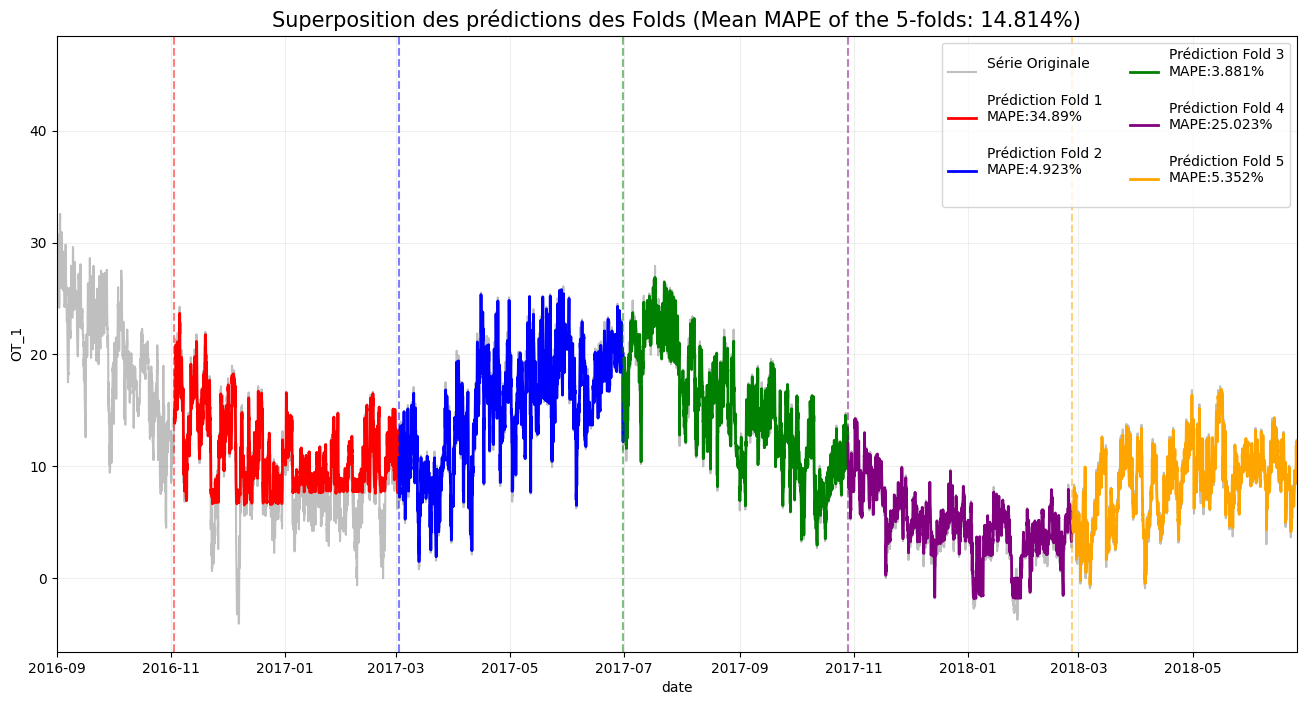

In [45]:
plt.figure(figsize=(16, 8))

plt.plot(univariate.index, univariate['OT_1'], label='Série Originale\n', color='gray', alpha=0.5)

colors = ['red', 'blue', 'green', 'purple', 'orange']

fold = 0
for idx, (train_idx, test_idx) in enumerate(tss.split(univariate_train)):
    val_dates = univariate_train.index[test_idx]
    y_pred = preds[fold]

    plt.plot(val_dates, y_pred, 
             color=colors[fold], 
             label=f'Prédiction Fold {fold+1}\nMAPE:{round(MAPEs[idx],3)}%\n', 
             linewidth=2)
    plt.axvline(val_dates.min(), color=colors[fold], linestyle='--', alpha=0.5)
    print(f"Min date of {idx}-fold :", val_dates.min())
    print(f"Max date of {idx}-fold :", val_dates.max(), "\n")
    fold += 1

plt.title(f"Superposition des prédictions des Folds (Mean MAPE of the {n_folds}-folds: {round(np.mean(MAPEs),3)}%)", fontsize=15)
plt.xlabel("date")
plt.ylabel("OT_1")
plt.xlim(pd.Timestamp('2016-09-01'), univariate_train.index.max())
plt.legend(loc='best', ncol=2)
plt.grid(True, alpha=0.2)
plt.show()

## Feature Importance

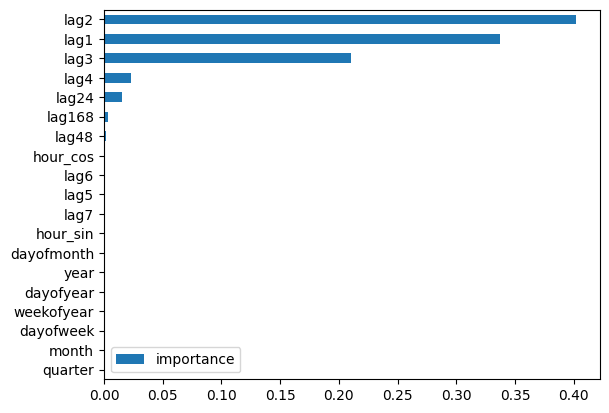

In [47]:
pd.DataFrame(data=regression.feature_importances_,
             index=regression.feature_names_in_,
             columns=["importance"]).sort_values("importance").plot(kind='barh')
plt.show()

## Prédictions sur les 24 dernières heures

17396 24


/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:09:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Performances sur 24h ---
RMSE	: 0.3230
MAPE	: 0.03%


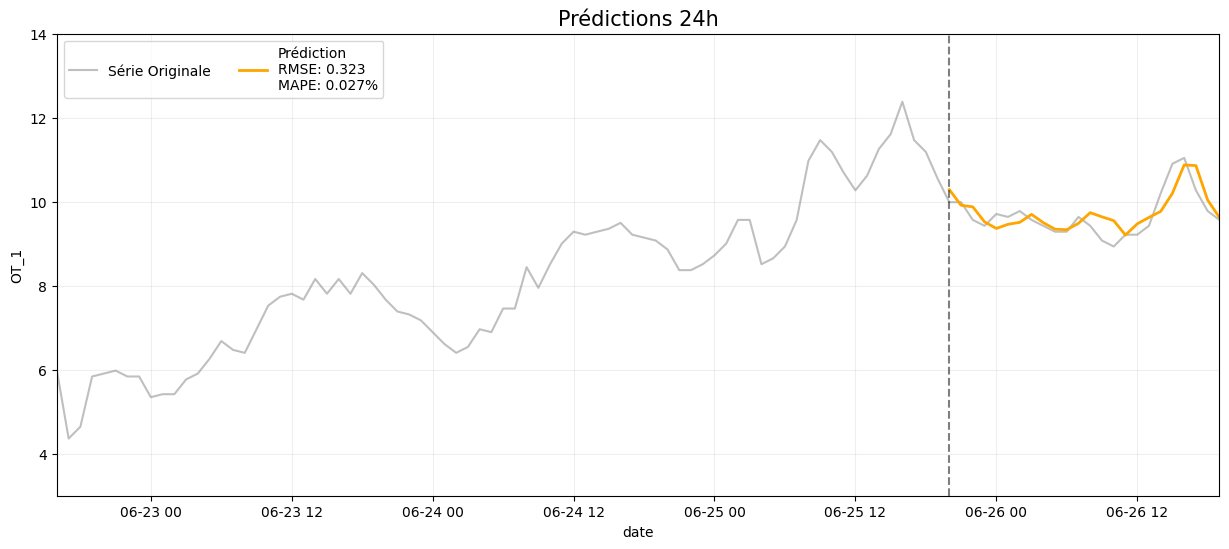

In [48]:
X_train = univariate_train[X]
y_train = univariate_train[y]

X_test = univariate_test[X]
y_test = univariate_test[y]

print(len(y_train), len(y_test))

regression = xgb.XGBRegressor(**clean_params1)
regression.fit(X_train, y_train,
                   eval_set=[(X_train, y_train), (X_test, y_test)],
                   verbose=False)
y_pred = regression.predict(X_test)


ONE_DAY_TESTSIZE = 24
ONE_DAY_RMSE = np.sqrt(mean_squared_error(y_test[-ONE_DAY_TESTSIZE:].values, y_pred[-ONE_DAY_TESTSIZE:]))
ONE_DAY_MAPE = np.mean(np.abs((y_test[-ONE_DAY_TESTSIZE:].values - y_pred[-ONE_DAY_TESTSIZE:]) / y_test[-ONE_DAY_TESTSIZE:].values))

print(f"--- Performances sur {ONE_DAY_TESTSIZE}h ---")
print(f"RMSE\t: {ONE_DAY_RMSE:.4f}")
print(f"MAPE\t: {ONE_DAY_MAPE:.2f}%")

plt.figure(figsize=(15, 6))
plt.plot(univariate.index, univariate['OT_1'], label='Série Originale', color='gray', alpha=0.5)

test_dates = univariate.index[-24:]

plt.plot(test_dates, y_pred[-24:], 
             color="orange",
                label=f'Prédiction\nRMSE: {round(ONE_DAY_RMSE,3)}\nMAPE: {round(ONE_DAY_MAPE,3)}%', 
             linewidth=2)
plt.axvline(test_dates.min(), color="black", linestyle='--', alpha=0.5)

plt.title("Prédictions 24h", fontsize=15)
plt.xlabel("date")
plt.ylabel("OT_1")
plt.xlim(univariate.index.max() - pd.Timedelta("99 hours"), univariate.index.max())
plt.legend(loc='best', ncol=2)
plt.grid(True, alpha=0.2)
plt.ylim(3,14)
plt.show()

## Prediction sur le futur

In [141]:
X_all = df[X]
y_all = df[y]

regression2 = xgb.XGBRegressor(n_estimators=200,
                                  max_depth=3,
                                  learning_rate=0.1,
                                  objective="reg:linear",
                                  n_jobs=-1,
                                  subsample=0.8,
                                  colsample_bytree=1.0,
                                  random_state=42)

regression2.fit(X_all, y_all,
                eval_set=[(X_all, y_all)],
                verbose=20)

NameError: name 'df' is not defined

In [ ]:
df.index.max()
futur_range_to_pred = pd.date_range(df.index.max(), df.index.max() + pd.Timedelta("1 day"), freq="1h")
df_futur = pd.DataFrame(index=futur_range_to_pred)
df_futur['isFuture']=True
df['isFuture']=False
df_and_future = pd.concat([df, df_futur])
df_and_future = create_features(df_and_future)
df_and_future = add_lags(df_and_future)

In [ ]:
future_w_features = df_and_future[df_and_future['isFuture']==True].copy()

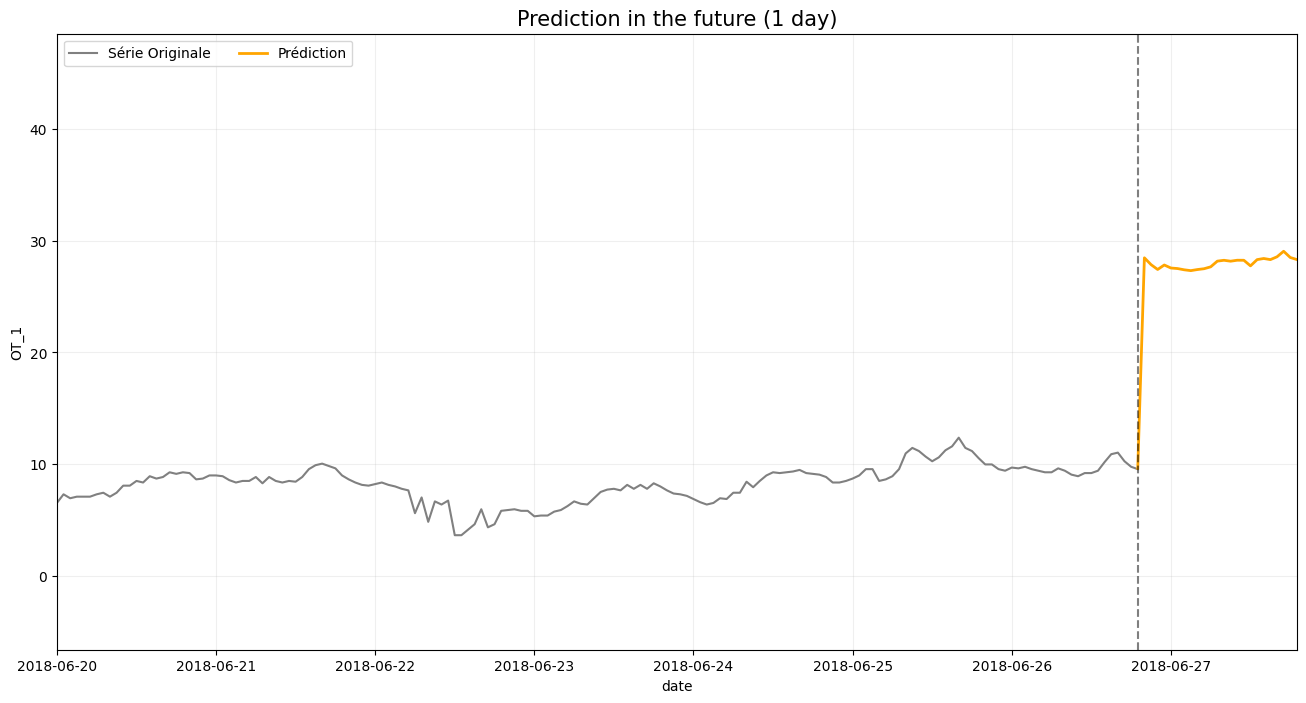

In [ ]:
future_w_features['preds'] = regression2.predict(future_w_features[X])


plt.figure(figsize=(16, 8))
plt.plot(univariate.index, univariate['OT_1'], label='Série Originale', color='gray', alpha=1)

plt.plot(future_w_features['preds'], 
             color="orange", 
             label=f'Prédiction', 
             linewidth=2)
plt.axvline(univariate.index.max(), color="black", linestyle='--', alpha=0.5)


plt.title("Prediction in the future (1 day)", fontsize=15)
plt.xlabel("date")
plt.ylabel("OT_1")
plt.xlim(pd.Timestamp('2018-06-20'), future_w_features.index.max())
plt.legend(loc='best', ncol=2)
plt.grid(True, alpha=0.2)
plt.show()

# Modélisation de la série multivariée

Faire du forecasting sur une série multivariée avec un modèle de Machine Learning comme XGBoost n'est pas un problème si ancien :
- Introduction de XGBoost : Chen & Guestrin (2016) — "XGBoost: A Scalable Tree Boosting System"
- La référence de forecasting multivariée avec XGB : Elsayed et al. (2021) — "Do We Really Need Deep Learning Models for Time Series Forecasting?"
    - Le problème de forecasting est tourné en régression supervisé par fenêtre glissante (window-based regression)(avec des lags).
    - Comparaison de l'univarié et du multivarié, dont la clé est tout simplement la Feature Engineering, comme dans beaucoup de cas en Machine Learning
- De nouvelles prouesses en forecasting avec le ML : Bojer & Meldgaard (2022) — "Forecasting with Gradient Boosted Trees: Augmentation, Tuning, and Cross-Validation Strategies" 
    - Meilleurs résultats que des modèles de Deep Learning sur la compétition "M5 Uncertainty"

Aucune version de GBRT Naïve ne sera implémentée, car incohérente avec le système réel, et sans intérêt particulier (sauf à titre de comparaison comme baseline).

window-based regression framework : 
- Processus AR, à la seule différence que ce n'est pas une régression linéaire type SOMME(\alpha_i*y_{t-i}), mais n'importe quel type de régresseur (donc aussi non-lineaire) comme XGBoost (arbres).

La puissance de l'approche ML est la non-linéarité, et la possibilité d'utiliser diverses features

"Do We Really Need Deep Learning Models for Time Series Forecasting?":
- Output multivarié : chaque série est prédite
- Stratégie MIMO : Un seul modèle GBRT multi-output  qui, à partir de la fenêtre aplatie de toutes les séries, prédit directement l'horizon complet en une seule passe([y(t+1), ... y(t+h)], ce qui évite la propagation d'erreur de la stratégie récursive). Capture les dépendances entre horizons.

**Pourquoi cette méthode ?:**

XGB Naif est une classique régression d'un point Y_t à l'aide des données des covariables à t, ce qui suppose que l'on a dejà les données à t des covariables, et qu'on estime donc la target à t en fonction. Or, dans notre système physique et réel, les données de la target et des covariables sont dépendantes, et mesurées en même temps sur le même système. Cette méthode est donc impossible. De plus, elle ne prend pas en compte la temporalité, ignore les valeurs passées de Y et des covariables

En se basant sur les datasets de tests du papier, le notre ressemble le plus a Beijing PM2.5 et Urban Air Quality : 1 targets, 1 instance (ici un seul transformer eléctrique), et plusieurs covariables (ainsi que fréquence horaire). Sur ces datasets, le GBRT(w-b) est le meilleur sur les RMSE des deux datasets, et deuxième sur la MAE de Air Quality à 5 dixième du GBRT Naive (meilleur MAE sur PM2.5), donc le modèle s'annonce prometteur, et sur-performe à chaque fois les modèles complexes types DNN/RNN/CNN.

In [49]:
"""
    XGBoostWB_Forecasting_Using_Hybrid_DL_Framework_Pm2.5_(1,6)
    source : https://github.com/Daniela-Shereen/GBRT-for-TSF/tree/main
"""
import random
from sklearn.multioutput import MultiOutputRegressor

n_folds=5
test_size=2880
num_periods_output  = 1 # HORIZON TO PREDICT
num_periods_input   = 24  # w, la window
ALL_Test_Data, ALL_Test_Prediction =[], []

In [50]:
# Reprise de la méthode générale du code du papier, en faisant directement l'opération pour ne conserver que la dernière valeur des covariables (vs en post-process dans le code original)
# Des suppressions de reshaping inutiles

def preprocessing(df_, num_periods_output=1, test_size=freq_data_day * 120):  # Soit 120j à prédire car h=24, ~16.5% du dataset (référence pour le dataset)
    
    df_['DayofWeek']=df_.index.dayofweek
    df_['Week']=df_.index.isocalendar().week
    df_['dayofyear']=df_.index.dayofyear
    Train=df_.iloc[:len(df_) - test_size]
    Test=df_.iloc[len(df_) - test_size:]

    #################################################################################

    COVARIABLES = df_.drop(columns=["OT_1"], inplace=False).columns
    TARGET = "OT_1"
        
    #############################  Normalization on train  #############
    X_train = Train[COVARIABLES]
    y_train = Train[TARGET]

    normalizer = MinMaxScaler().fit(X_train)
    X_train=normalizer.transform(X_train)

    y_train=np.reshape(y_train,(len(y_train),1))
    Train=np.append(y_train, X_train, axis=1)   #rajout de la target après normalisation des covariables, unique set d'entrainement
    
    ############################################ TRAIN windows ##################################
    end=len(Train)
    start=0
    next=0
    x_batches=[]
    y_batches=[]
    
    limit = num_periods_output + num_periods_input
    while start + limit <= end:
        next = start + num_periods_input
        
        # lags de y uniquement (colonne 0)
        y_lags = Train[start:next, 0]
        
        # covariables à t (dernière ligne de la fenêtre, colonnes 1:) on exclut target indice 0
        X_t = Train[next-1, 1:]
        
        # concat → vecteur plat
        x_batches.append(np.concatenate([y_lags, X_t]))
        y_batches.append(Train[next:next+num_periods_output, 0])
        start += 1

    x_batches=np.asarray(x_batches) # x_batches size   = N_windows
                                    # One window size = (w,num_features)
                                    # Now same but NumPy Array (instead of a Python list)
    y_batches=np.asarray(y_batches)
    
    ###########################################TEST Normalization##################################
    y_test=Test[TARGET]
    X_test=Test[COVARIABLES]

    X_test=normalizer.transform(X_test) 

    y_test=np.reshape(y_test, (len(y_test), 1))
    Test=np.append(y_test, X_test, axis=1)
    ############################################ TEST windows ##################################
    end_test=len(Test)
    start_test=0
    next_test=0
    x_testbatches=[]
    y_testbatches=[]

    while start_test+(limit)<=end_test:
        next_test = start_test + num_periods_input
        y_lags = Test[start_test:next_test, 0]
        X_t = Test[next_test-1, 1:]
        x_testbatches.append(np.concatenate([y_lags, X_t]))
        y_testbatches.append(Test[next_test:next_test + num_periods_output, 0])
        start_test = start_test+num_periods_output #incrémente par l'horizon

    x_testbatches=np.asarray(x_testbatches)
    y_testbatches=np.asarray(y_testbatches)
    
    return x_batches, y_batches, x_testbatches, y_testbatches

In [51]:
data=df1.copy()
All_Training_Instances, y_batches, All_Testing_Instances, Y_Test = preprocessing(data, test_size = 24+24)

#---------------------shuffle minibatches X and Y together-------------------------------------
combined = list(zip(All_Training_Instances, y_batches))
random.seed(42)
random.shuffle(combined)
shuffled_batch_features, shuffled_batch_y = zip(*combined)

# len(shuffled_batch_features) <> 17396 car suppression de "24" par le paramètre WINDOW en TRAIN et de "24" par WINDOW en TEST, donc len(shuffled_batch_features) = 17396 - 24 - 24

In [52]:
tscv = TimeSeriesSplit(n_splits=n_folds, test_size=test_size, gap=24)

base_model = xgb.XGBRegressor()
multi_model = MultiOutputRegressor(base_model)

param_dist = {
    'estimator__n_estimators': [1500],
    'estimator__subsample': [0.8, 1],
    'estimator__colsample_bytree': [0.8, 1],
    'estimator__learning_rate': [0.01],
    'estimator__max_depth': [1, 2],
    'estimator__min_samples_split': [1, 2, 3],
    'estimator__scale_pos_weight': [0.8, 1],
    'estimator__n_jobs': [-1],
    'estimator__random_state': [42],

}

random_search2 = RandomizedSearchCV(
    multi_model, 
    param_distributions=param_dist, 
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_iter=150,
    n_jobs=-1
)

random_search2.fit(shuffled_batch_features, shuffled_batch_y)
best_params2 = random_search2.best_params_
clean_params2 = {k.replace('estimator__', ''): v for k, v in best_params2.items()}
print("Paramètres optimaux extraits :", clean_params2)

/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 48 is smaller than n_iter=150. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:09:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:09:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: 

Paramètres optimaux extraits : {'subsample': 0.8, 'scale_pos_weight': 0.8, 'random_state': 42, 'n_jobs': -1, 'n_estimators': 1500, 'min_samples_split': 1, 'max_depth': 2, 'learning_rate': 0.01, 'colsample_bytree': 1}


In [ ]:
shift_value2 = np.abs(np.min(Y_Test)) +1
y_test_shifted2 = Y_Test + shift_value2

preds2, scores2, MAPEs2 = [], [], []
for i in range(n_folds):
    X_tr, y_tr, X_te, y_te = preprocessing(data, test_size=test_size*(n_folds - i) + num_periods_input)

    X_te = X_te[:test_size]
    y_te = y_te[:test_size] # only one fold


    model=xgb.XGBRegressor(**clean_params2)
    multioutput=MultiOutputRegressor(model).fit(X_tr,
                                                y_tr,
                                                verbose=20)
    y_pred = multioutput.predict(X_te)
    preds2.append(y_pred)
    score = np.sqrt(mean_squared_error(y_te, y_pred))
    scores2.append(score)

    preds_shifted = y_pred + shift_value2
    y_test_shifted = y_te + shift_value2
    mape = np.mean(np.abs((y_test_shifted - preds_shifted) / y_test_shifted)) * 100
    MAPEs2.append(mape)
    print(f"MAPE : {mape:.3f}%")


/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:12:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MAPE : 8.089%


/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:12:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MAPE : 3.067%


/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:12:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MAPE : 2.503%


/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:12:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MAPE : 4.936%


/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:12:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MAPE : 2.520%


In [60]:
print("Mean MAPE of the k-folds:", round(np.mean(MAPEs2),3),"%")
print(f"RMSE Score across folds (mean) : {np.mean(scores2):.3f}")
print(f"Folds scores : {[round(score,3) for score in scores2]}")

Mean MAPE of the k-folds: 4.223 %
RMSE Score across folds (mean) : 1.060
Folds scores : [np.float64(1.888), np.float64(1.046), np.float64(0.882), np.float64(0.837), np.float64(0.647)]


Previous univariate method :
- Score across folds (mean) : 1.037
- Folds scores : [np.float64(1.713), np.float64(1.1), np.float64(0.931), np.float64(0.738), np.float64(0.702)]

2016-11-03 20:00:00
2017-03-03 19:00:00 

2017-03-03 20:00:00
2017-07-01 19:00:00 

2017-07-01 20:00:00
2017-10-29 19:00:00 

2017-10-29 20:00:00
2018-02-26 19:00:00 

2018-02-26 20:00:00
2018-06-26 19:00:00 



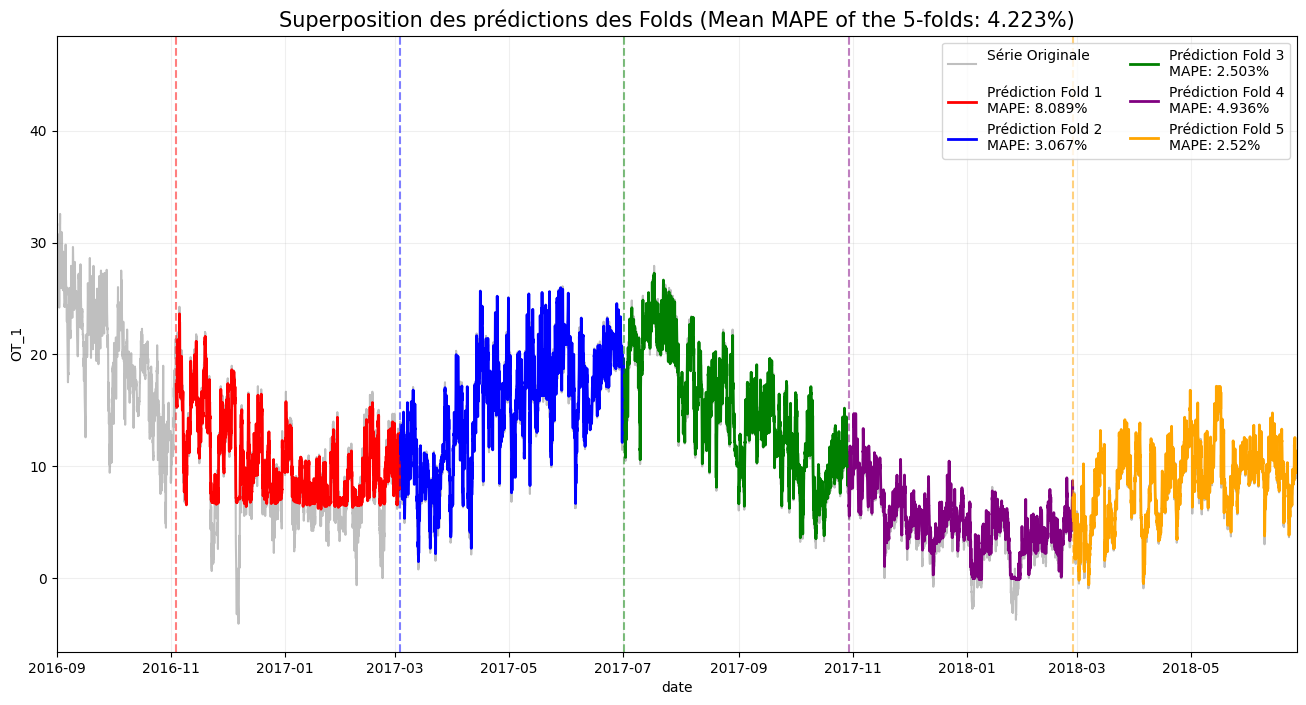

In [87]:
# A REFAIRE ! IL PREDIT LE TEST SET


plt.figure(figsize=(16, 8))
plt.plot(df1.index, df1['OT_1'], label='Série Originale\n', color='gray', alpha=0.5)

colors = ['red', 'blue', 'green', 'purple', 'orange']

fold = 0
sizes = dict()

for idx, val in enumerate(preds2):
    sizes[idx]=len(val)

for idx, val in enumerate(preds2):
    count=0
    test_size_preds2=[]
    while (len(sizes)-count) != idx:
        test_size_preds2.append(sizes[count+idx])
        count+=1
    
    test_start = len(df1) - sum(test_size_preds2)
    test_end   = test_start + test_size_preds2[0]

    test_dates = df1.index[test_start:test_end]
    y_pred = val

    plt.plot(test_dates, y_pred, 
             color=colors[fold], 
             label=f'Prédiction Fold {fold+1}\nMAPE: {round(MAPEs2[idx],3)}%', 
             linewidth=2)
    plt.axvline(test_dates.min(), color=colors[fold], linestyle='--', alpha=0.5)
    print(test_dates.min())
    print(test_dates.max(),"\n")

    fold += 1

plt.title(f"Superposition des prédictions des Folds (Mean MAPE of the {n_folds}-folds: {round(np.mean(MAPEs2),3)}%)", fontsize=15)
plt.xlabel("date")
plt.ylabel("OT_1")
plt.xlim(pd.Timestamp('2016-09-01'), df1.index.max())
plt.legend(loc='best', ncol=2)
plt.grid(True, alpha=0.2)
plt.show()

### Prédictions sur le test_set (24H) avec HORIZON=1

In [69]:
model_test_set=xgb.XGBRegressor(**clean_params2)
multioutput_test_set=MultiOutputRegressor(model).fit(shuffled_batch_features,
                                                shuffled_batch_y,
                                                verbose=20)
prediction_test_set=multioutput_test_set.predict(All_Testing_Instances)
print('prediction ',prediction_test_set.shape)
print('test ',Y_Test.shape)
MSE=np.mean(( prediction_test_set- Y_Test)**2)
print('RMSE: ',round(MSE**0.5,4))
MAE=np.mean(np.abs( prediction_test_set- Y_Test))
print('MAE: ',round(MAE,4))

# Because some values of Y_Test are 0 or very close, we shift the series.
shift_value = np.abs(np.min(Y_Test)) +1
Y_Test_shifted = Y_Test + shift_value
prediction_shifted = prediction_test_set + shift_value
MAPE=np.mean(np.abs(Y_Test_shifted - prediction_shifted) / Y_Test_shifted) * 100
print('MAPE: ',round(MAPE,3),"%")

/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:14:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


prediction  (24, 1)
test  (24, 1)
RMSE:  0.3922
MAE:  0.3219
MAPE:  1.642 %


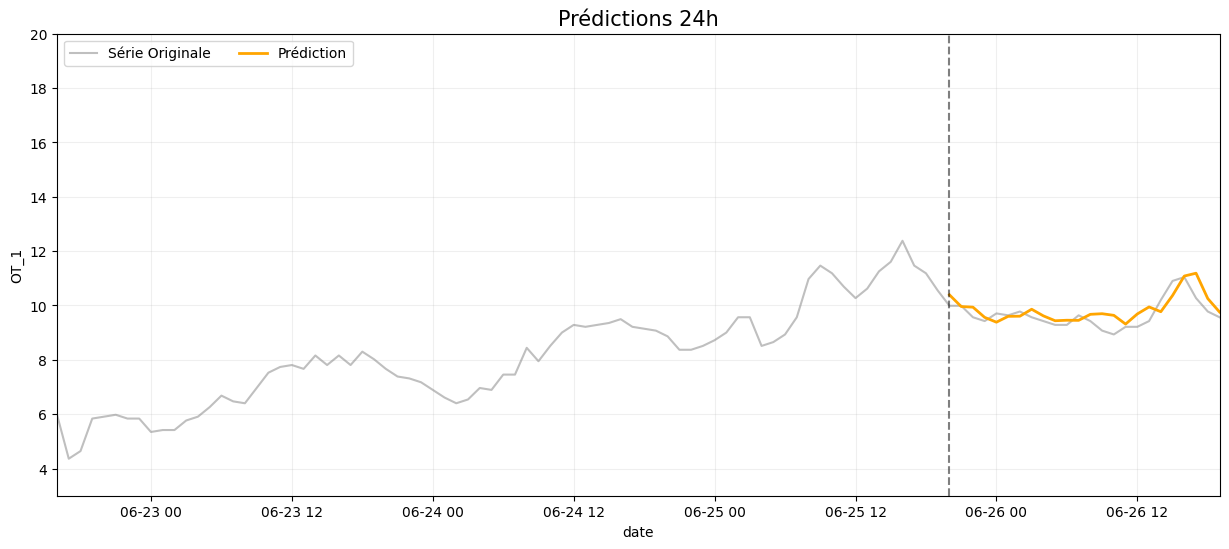

In [ ]:
# HORIZON = 1

plt.figure(figsize=(15, 6))
plt.plot(df1.index, df1['OT_1'], label='Série Originale', color='gray', alpha=0.5)

plt.plot(df1.index[-24:],
        prediction_test_set, 
        color="orange", 
        label=f'Prédiction', 
        linewidth=2)

plt.axvline(df1.index[-24:].min(), color="black", linestyle='--', alpha=0.5)

plt.title(f"Prédictions {24}h", fontsize=15)
plt.xlabel("date")
plt.ylabel("OT_1")
plt.xlim(df1.index[-24:].max() - pd.Timedelta("99 hours"), df1.index.max())
plt.legend(loc='best', ncol=2)
plt.grid(True, alpha=0.2)
plt.ylim(3,20)
plt.show()

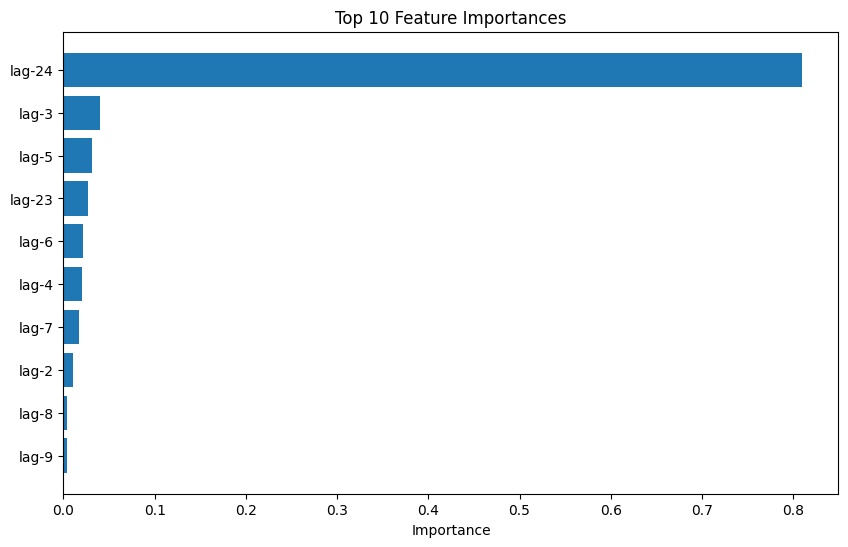

In [88]:
importances = multioutput_test_set.estimators_[0].feature_importances_

headers = [f"lag-{i}" for i in range(1,num_periods_input+1)]
covariables = ["MUFL_1", "MULL_1", "LUFL_1", "LULL_1", "DayofWeek", "Week", "dayofyear"]
headers.extend(covariables)

df_importance = pd.DataFrame({
    'Feature': headers,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
plt.barh(df_importance['Feature'][:10], df_importance['Importance'][:10])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

### Prédictions sur le test_set (24H) avec HORIZON=24

In [ ]:
horizon  = 24
n_test=24

X_train24, y_train24, X_test24, y_test24 = preprocessing(data, num_periods_output=horizon, test_size=n_test+num_periods_input)

#---------------------shuffle minibatches X and Y together-------------------------------------
combined = list(zip(X_train24, y_train24))
random.seed(42)
random.shuffle(combined)
X_train24, y_train24 = zip(*combined)


# tscvHorizon24 = TimeSeriesSplit(n_splits=n_folds, test_size=test_size, gap=24)
# base_model_Horizon24 = xgb.XGBRegressor()
# multi_model_Horizon24 = MultiOutputRegressor(base_model_Horizon24)

# param_dist_Horizon24 = {
#     'estimator__n_estimators': [3000],
#     'estimator__subsample': [0.8, 1],
#     'estimator__colsample_bytree': [0.8, 1],
#     'estimator__learning_rate': [0.01],
#     'estimator__max_depth': [5,6,7],
#     'estimator__min_samples_split': [1, 2, 3],
#     'estimator__scale_pos_weight': [0.8, 1],
#     'estimator__n_jobs': [-1],
#     'estimator__random_state': [42],

# }

# random_search_Horizon24 = RandomizedSearchCV(
#     multi_model_Horizon24, 
#     param_distributions=param_dist_Horizon24, 
#     cv=tscvHorizon24,
#     scoring='neg_mean_squared_error',
#     n_iter=150,
#     n_jobs=-1
# )

# random_search_Horizon24.fit(X_train24, y_train24)
# best_params_Horizon24 = random_search_Horizon24.best_params_
# clean_params_Horizon24 = {k.replace('estimator__', ''): v for k, v in best_params_Horizon24.items()}
# print("Paramètres optimaux extraits pour horizon=24 :", clean_params_Horizon24)



# model_Horizon24=xgb.XGBRegressor(**clean_params_Horizon24)
# multioutput_Horizon24=MultiOutputRegressor(model_Horizon24).fit(X_train24,
#                                                 y_train24,
#                                                 verbose=20)


/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 48 is smaller than n_iter=150. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [21:31:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [21:31:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: 

Paramètres optimaux extraits pour horizon=24 : {'subsample': 0.8, 'scale_pos_weight': 0.8, 'random_state': 42, 'n_jobs': -1, 'n_estimators': 3000, 'min_samples_split': 1, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 1}


/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [22:14:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [22:14:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [22:14:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: Us

In [ ]:
clean_params_Horizon24 = {'subsample': 0.8,
 'scale_pos_weight': 0.8,
 'random_state': 42,
 'n_jobs': -1,
 'n_estimators': 3000,
 'min_samples_split': 1,
 'max_depth': 7,
 'learning_rate': 0.01,
 'colsample_bytree': 1}

model_Horizon24=xgb.XGBRegressor(**clean_params_Horizon24)
multioutput_Horizon24=MultiOutputRegressor(model_Horizon24).fit(X_train24,
                                                y_train24,
                                                verbose=20)


/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [22:27:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [22:27:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [22:27:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/xgboost/training.py:200: Us

WINDOW = 24:
- RMSE:  0.915
- MAE:  0.8225
- MAPE:  4.222 %

WINDOW = 168: #7j


prediction  (24,)
test  (1, 24)
RMSE:  0.915
MAE:  0.8225
MAPE:  4.222 %


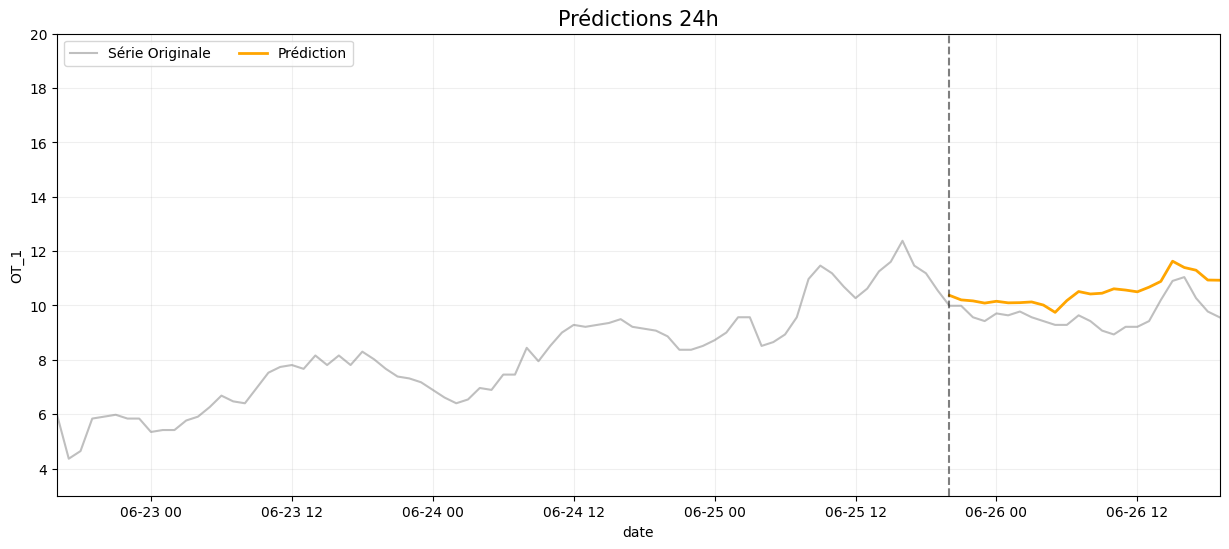

In [ ]:
pred_Horizon24 = multioutput_Horizon24.predict(X_test24)[0]

print('prediction ',pred_Horizon24.shape)
print('test ',y_test24.shape)
MSE=np.mean(( pred_Horizon24- y_test24)**2)
print('RMSE: ',round(MSE**0.5,4))
MAE=np.mean(np.abs( pred_Horizon24- y_test24))
print('MAE: ',round(MAE,4))

# Because some values of y_test24 are 0 or very close, we shift the series.
shift_value = np.abs(np.min(y_test24)) +1
y_test24_shifted = y_test24 + shift_value
prediction_shifted = pred_Horizon24 + shift_value
MAPE=np.mean(np.abs(y_test24_shifted - prediction_shifted) / y_test24_shifted) * 100
print('MAPE: ',round(MAPE,3),"%")



# HORIZON = 24
plt.figure(figsize=(15, 6))
plt.plot(df1.index, df1['OT_1'], label='Série Originale', color='gray', alpha=0.5)

plt.plot(df1.index[-n_test:],
        pred_Horizon24, 
        color="orange", 
        label=f'Prédiction', 
        linewidth=2)

plt.axvline(df1.index[-n_test:].min(), color="black", linestyle='--', alpha=0.5)

plt.title(f"Prédictions {n_test}h", fontsize=15)
plt.xlabel("date")
plt.ylabel("OT_1")
plt.xlim(df1.index[-n_test:].max() - pd.Timedelta("99 hours"), df1.index.max())
plt.legend(loc='best', ncol=2)
plt.grid(True, alpha=0.2)
plt.ylim(3,20)
plt.show()